Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
Tuned Accuracy: 0.875

Confusion Matrix:
[[66 11]
 [12 95]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.85        77
           1       0.90      0.89      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



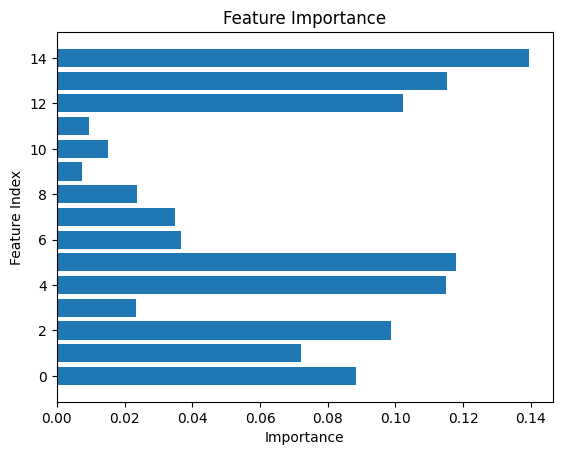

In [3]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Load preprocessed data
X_train, X_test, y_train, y_test = pickle.load(open("processed_data.pkl", "rb"))

# Define Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Parameter grid for tuning
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# GridSearch with StratifiedKFold
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=skf,
    n_jobs=-1,
    verbose=2
)

# Train model
grid.fit(X_train, y_train)

# Best model
best_rf = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# Predictions
y_pred = best_rf.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Tuned Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance
importances = best_rf.feature_importances_
features = np.arange(len(importances))

plt.barh(features, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature Index")
plt.show()

# Save tuned model
pickle.dump(best_rf, open("random_forest_model.pkl", "wb"))

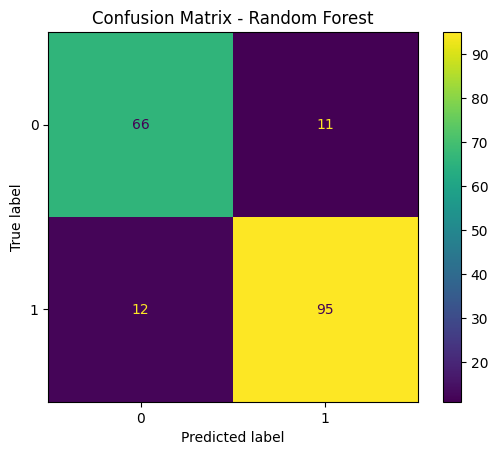

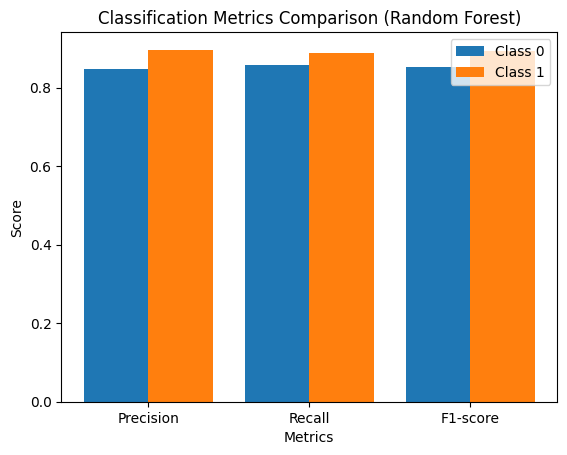

ROC-AUC Score: 0.9367034834324555


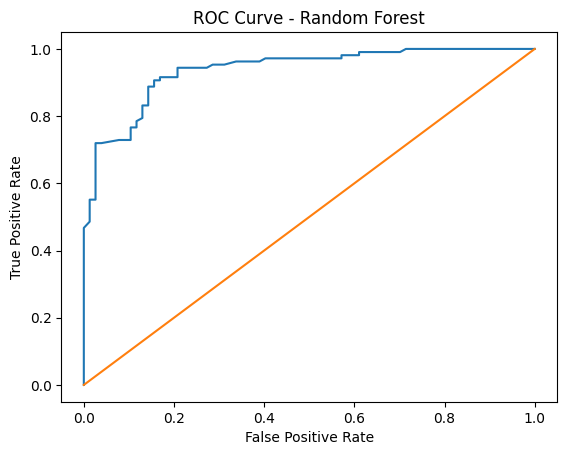

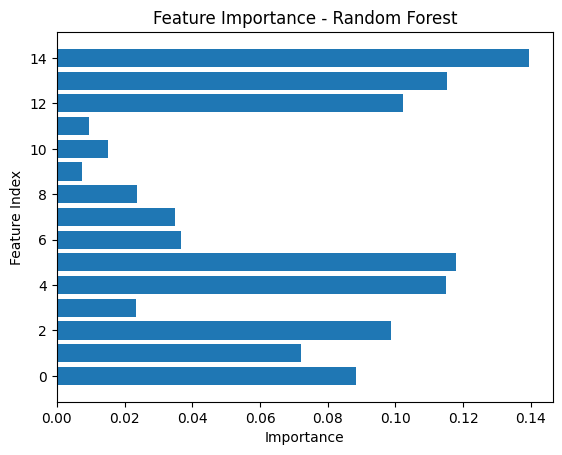

In [2]:

import pickle

# Load processed data
X_train, X_test, y_train, y_test = pickle.load(open("processed_data.pkl", "rb"))

# Load trained model
best_rf = pickle.load(open("random_forest_model.pkl", "rb"))

# Generate predictions
y_pred = best_rf.predict(X_test)

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)


cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()


report = classification_report(y_test, y_pred, output_dict=True)

labels = ['Precision', 'Recall', 'F1-score']

class_0 = [
    report['0']['precision'],
    report['0']['recall'],
    report['0']['f1-score']
]

class_1 = [
    report['1']['precision'],
    report['1']['recall'],
    report['1']['f1-score']
]

x = np.arange(len(labels))

plt.figure()
plt.bar(x - 0.2, class_0, width=0.4)
plt.bar(x + 0.2, class_1, width=0.4)

plt.xticks(x, labels)
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Classification Metrics Comparison (Random Forest)")
plt.legend(["Class 0", "Class 1"])

plt.show()



y_prob = best_rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

print("ROC-AUC Score:", auc_score)

plt.show()



importances = best_rf.feature_importances_
features = np.arange(len(importances))

plt.figure()
plt.barh(features, importances)

plt.xlabel("Importance")
plt.ylabel("Feature Index")
plt.title("Feature Importance - Random Forest")

plt.show()